## 1.Loading the Dataset

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Suppress all FutureWarnings to keep the output clean
warnings.filterwarnings("ignore", category=FutureWarning)

# Load the data 
df = pd.read_csv(r'C:\saas customer churn prediction\synthetic_customer_behavior_and_churn.csv')

# Initial sanity check
print("Shape: \n", df.shape, "\n\nInfo:")
print(df.info(), "\n\nNull count:")
print(df.isnull().sum())

Shape: 
 (15000, 21) 

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   15000 non-null  object 
 1   signup_date                   15000 non-null  object 
 2   tenure_months                 15000 non-null  int64  
 3   age                           15000 non-null  int64  
 4   gender                        15000 non-null  object 
 5   region                        15000 non-null  object 
 6   income_level                  15000 non-null  object 
 7   subscription_type             15000 non-null  object 
 8   monthly_charges               15000 non-null  float64
 9   total_charges                 15000 non-null  float64
 10  usage_frequency               15000 non-null  object 
 11  avg_session_duration_minutes  15000 non-null  float64
 12  number_of_logins_per_month    1

In [68]:
df.head()

,customer_id,signup_date,tenure_months,age,gender,region,income_level,subscription_type,monthly_charges,total_charges,...,avg_session_duration_minutes,number_of_logins_per_month,number_of_support_tickets,satisfaction_score,payment_method,contract_type,last_login_days_ago,promotional_response,discount_used,churn
0,CUST_000001,2022-08-17,28,47,Male,North America,low,basic,35.22,1034.06,...,55.3,12,1,5,Credit Card,monthly,4,no,yes,0
1,CUST_000002,2022-02-21,34,40,Male,Europe,low,standard,63.56,2065.11,...,25.7,18,1,3,Bank Transfer,yearly,13,no,yes,0
2,CUST_000003,2023-07-18,17,49,Female,Asia Pacific,low,standard,74.37,1248.11,...,9.0,8,6,5,Digital Wallet,monthly,54,no,yes,1
3,CUST_000004,2023-05-17,19,60,Female,Latin America,medium,premium,98.28,1540.50,...,99.4,30,1,3,Credit Card,monthly,6,no,no,0
4,CUST_000005,2023-04-03,20,39,Female,Asia Pacific,medium,standard,61.47,1166.17,...,8.4,8,3,5,Digital Wallet,yearly,59,no,yes,0


## 2.EDA

Churn Rate: 31.89%


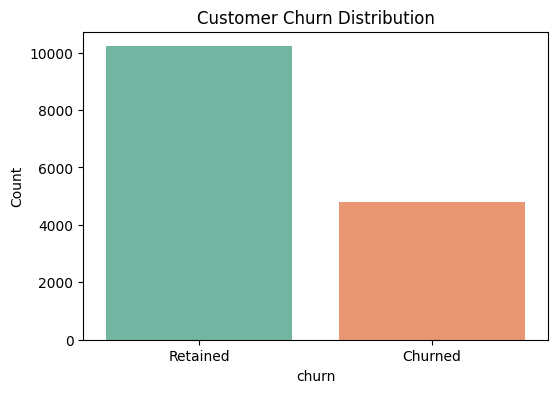

In [69]:
# Churn distribution
churn_counts = df['churn'].value_counts()
print(f"Churn Rate: {churn_counts[1] / len(df) * 100:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='churn', palette='Set2')
plt.title('Customer Churn Distribution')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.ylabel('Count')
plt.show()

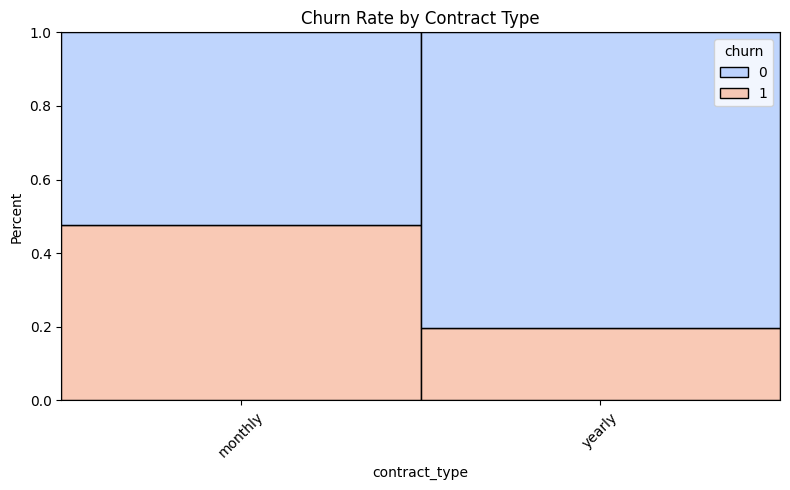

contract_type
monthly    0.476758
yearly     0.196809
Name: churn, dtype: float64


In [70]:
# Q1: Does contract type affect churn?
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='contract_type', hue='churn', multiple='fill', stat='percent', palette='coolwarm')
plt.title('Churn Rate by Contract Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print exact percentages
print(df.groupby('contract_type')['churn'].mean().sort_values(ascending=False))

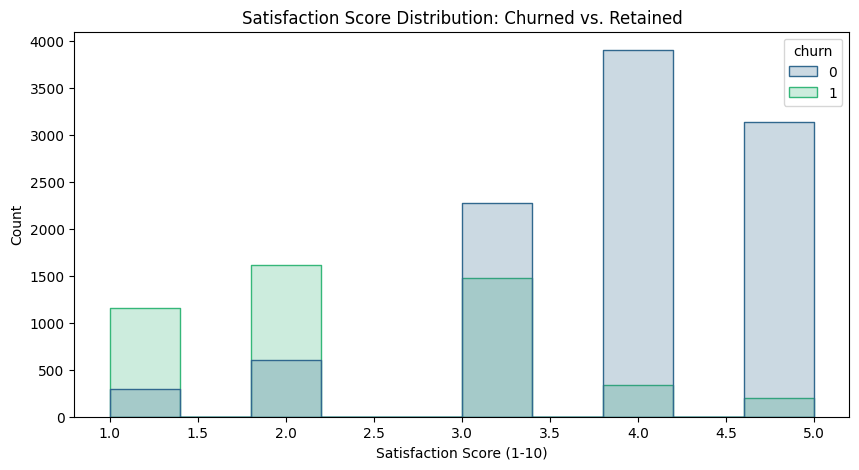

Correlation between satisfaction_score and churn: -0.578


In [71]:
# Q2: Is satisfaction score a strong predictor?
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='satisfaction_score', hue='churn', bins=10, kde=False, element='step', palette='viridis')
plt.title('Satisfaction Score Distribution: Churned vs. Retained')
plt.xlabel('Satisfaction Score (1-10)')
plt.show()

# Correlation check
print(f"Correlation between satisfaction_score and churn: {df['satisfaction_score'].corr(df['churn']):.3f}")

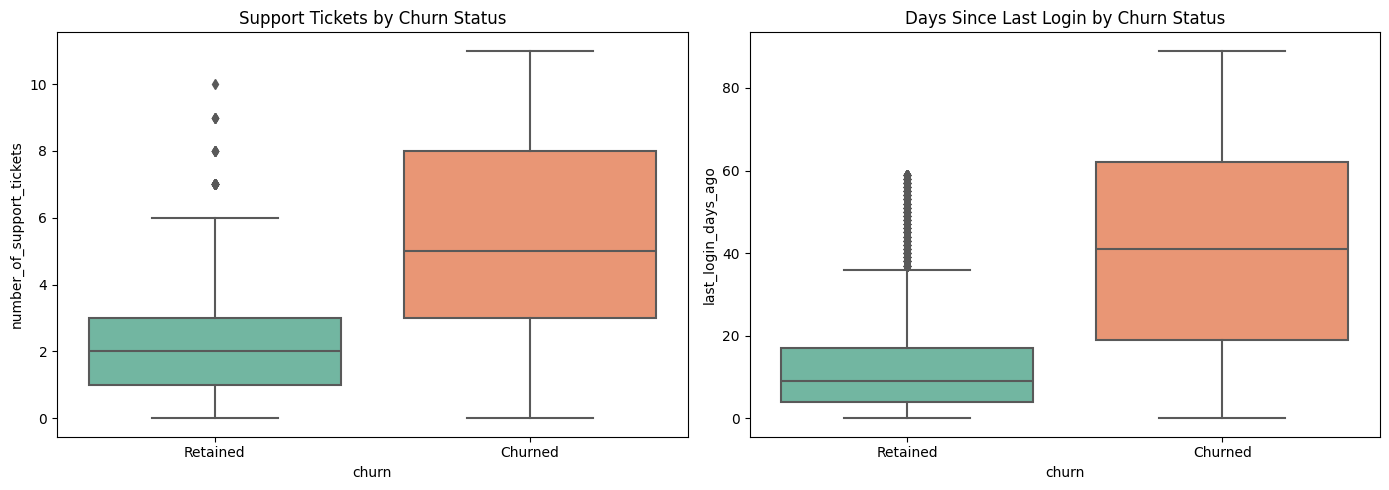

In [72]:
# Q3: Behavioral red flags — Support tickets & recency
# dashboard-style plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='churn', y='number_of_support_tickets', ax=axes[0], palette='Set2')
axes[0].set_title('Support Tickets by Churn Status')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained', 'Churned'])

sns.boxplot(data=df, x='churn', y='last_login_days_ago', ax=axes[1], palette='Set2')
axes[1].set_title('Days Since Last Login by Churn Status')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

### Monthly Users are approximately 2.5x more likely to churn compared to yearly users.
### Churned customers averaged 5 submitted support tickets, while retained customers averaged 2.
### Churned costumers averaged 40 days from their last login, while retained customers averaged 10.

## 3.Pre-Processing

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Drop non-predictive columns 
df_processed = df.drop(['customer_id', 'signup_date', 'churn'], axis=1).copy()
y = df['churn']  # Keep target separate

# 2. Feature Engineering 
# Engagement score: active hours per month
df_processed['engagement_score'] = (
    df_processed['number_of_logins_per_month'] * 
    df_processed['avg_session_duration_minutes'] / 60
)

# Support intensity: tickets normalized by tenure (+1 to avoid div by zero)
df_processed['support_intensity'] = (
    df_processed['number_of_support_tickets'] / 
    (df_processed['tenure_months'] + 1)
)

# Value per month: average revenue per month (ARPM)
df_processed['value_per_month'] = (
    df_processed['total_charges'] / 
    (df_processed['tenure_months'] + 1)
)

# Contract risk flag: 1 if month-to-month (EDA showed 2.5x churn!)
df_processed['contract_risk'] = (
    df_processed['contract_type'] == 'monthly'
).astype(int)

# 3. Identify column types
# Numerical features (including engineered ones)
num_features = [
    'tenure_months', 'age', 'monthly_charges', 'total_charges',
    'avg_session_duration_minutes', 'number_of_logins_per_month',
    'number_of_support_tickets', 'satisfaction_score',
    'last_login_days_ago', 'engagement_score', 'support_intensity',
    'value_per_month', 'contract_risk'  # contract_risk is numeric now
]

# Categorical features to encode
cat_features = [
    'gender', 'region', 'income_level', 'subscription_type',
    'usage_frequency', 'payment_method', 'contract_type',  # keep original for OHE
    'promotional_response', 'discount_used'
]

# 4. Train/Test Split (BEFORE scaling!)
X = df_processed.copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Preserve churn ratio in both sets
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Churn rate - Train: {y_train.mean():.2%}, Test: {y_test.mean():.2%}")

# 5. Preprocessing Pipeline 
# Numerical: scale
num_transformer = StandardScaler()

# Categorical: one-hot encode (handle unknown categories gracefully)
cat_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Combine into preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Fit preprocessor on TRAINING data only
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert back to DataFrame for SHAP interpretability later
feature_names = (
    num_features + 
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))
)
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

print(f"Final feature count: {X_train_df.shape[1]}")
print(f"Sample features: {feature_names[:10]}")

Training set: (12000, 22), Test set: (3000, 22)
Churn rate - Train: 31.88%, Test: 31.90%
Final feature count: 40
Sample features: ['tenure_months', 'age', 'monthly_charges', 'total_charges', 'avg_session_duration_minutes', 'number_of_logins_per_month', 'number_of_support_tickets', 'satisfaction_score', 'last_login_days_ago', 'engagement_score']


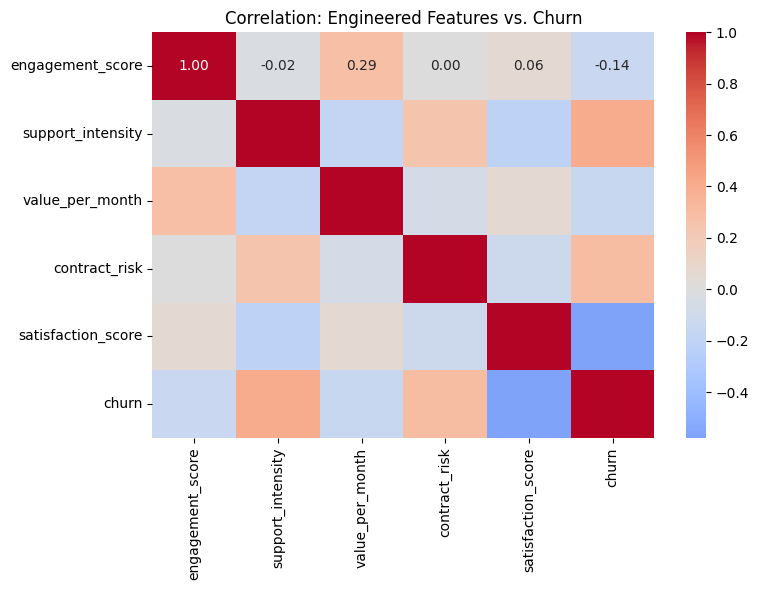

In [74]:
# Create a temporary dataframe for the correlation check
df_for_corr = df_processed.copy()
df_for_corr['churn'] = y  # Add the target back temporarily for visualization

# Define columns to check
corr_cols = ['engagement_score', 'support_intensity', 'value_per_month', 'contract_risk', 'satisfaction_score', 'churn']

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_for_corr[corr_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Correlation: Engineered Features vs. Churn')
plt.tight_layout()
plt.show()

## 4.Modeling with XGBoost & Class-Imbalance Handling

In [78]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score

# 1. Calculate scale_pos_weight 
# Formula: (Number of Negatives) / (Number of Positives)
# This tells the model: "A false negative is X times worse than a false positive"
negatives = (y_train == 0).sum()
positives = (y_train == 1).sum()
scale_pos_weight = negatives / positives

print(f"Training Class Distribution: {positives} churners, {negatives} retained")
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# 2. Initialize XGBoost Model 
# We use conservative, robust hyperparameters for tabular data
xgb_model = xgb.XGBClassifier(
    n_estimators=200,          # Number of trees
    max_depth=5,               # Prevents overfitting (keeps trees shallow)
    learning_rate=0.05,        # Slow, steady learning
    scale_pos_weight=scale_pos_weight, # CRITICAL for imbalanced data
    eval_metric='auc',         # Optimize for Area Under the ROC Curve
    random_state=42,
)

# 3. Train the Model 
print("Training XGBoost model...")
xgb_model.fit(X_train_processed, y_train)
print("Training Complete.")

# 4. Make Predictions 
# We need BOTH class predictions (0 or 1) AND probabilities (0.0 to 1.0)
y_pred = xgb_model.predict(X_test_processed)
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1] # Probability of class 1 (Churn)

Training Class Distribution: 3826 churners, 8174 retained
Calculated scale_pos_weight: 2.14
Training XGBoost model...
Training Complete.



🎯 ROC-AUC Score: 0.9780

📋 Classification Report:
              precision    recall  f1-score   support

Retained (0)       0.95      0.94      0.95      2043
 Churned (1)       0.88      0.90      0.89       957

    accuracy                           0.93      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.93      0.93      0.93      3000



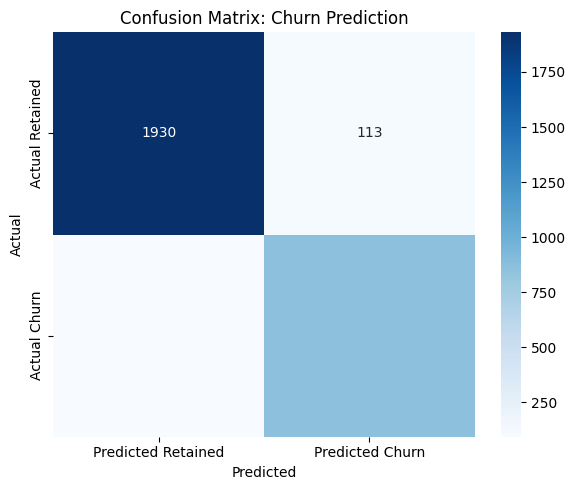

In [79]:
# 1. ROC-AUC Score 
# 0.5 = random guessing, 1.0 = perfect. >0.80 is generally considered good for business data.
roc_auc = roc_auc_score(y_test, y_prob)
print(f"\n🎯 ROC-AUC Score: {roc_auc:.4f}")

# 2. Classification Report 
# Focus on the F1-Score and Recall for class '1' (Churn)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

# 3. Business-Focused Confusion Matrix 
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Retained', 'Predicted Churn'],
            yticklabels=['Actual Retained', 'Actual Churn'])
plt.title('Confusion Matrix: Churn Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 5.Explaining the AI Model with SHAP

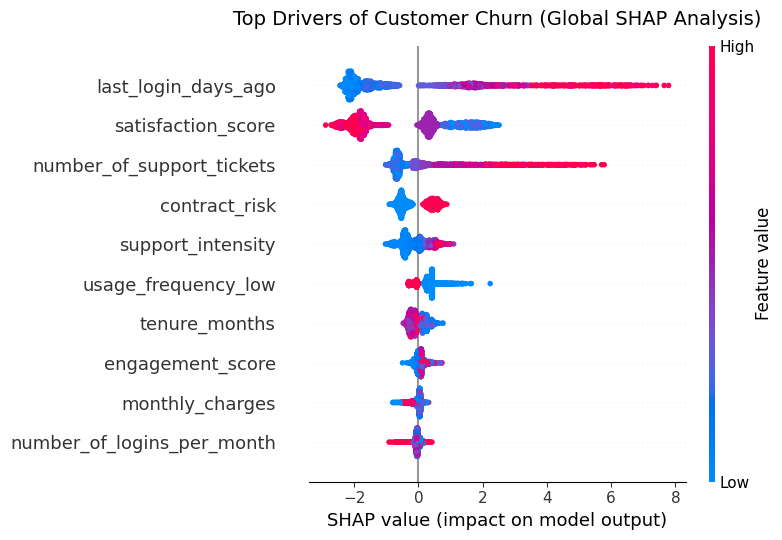

In [85]:
import shap

# 1. Initialize the TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

# 2. Calculate SHAP values
shap_values = explainer.shap_values(X_test_df)

# 3. Global Summary Plot (Fixed)
plt.figure(figsize=(10, 6))

# Add show=False so SHAP doesn't auto-display the plot
shap.summary_plot(shap_values, X_test_df, max_display=10, show=False) 

# Now the title applies to the correct, active plot
plt.title('Top Drivers of Customer Churn (Global SHAP Analysis)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [89]:
# 1. Pick a high-risk customer (probability > 85%)
high_risk_indices = np.where(y_prob > 0.85)[0]
sample_idx = high_risk_indices[0] # Pick the first one

# 2. Get SHAP values and feature names for this specific customer
sample_shap_values = shap_values[sample_idx]
feature_names = X_test_df.columns # This has the clean column names

# 3. Create a DataFrame to sort features by their absolute impact on the prediction
shap_impact_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': sample_shap_values,
    'Absolute_Impact': np.abs(sample_shap_values)
}).sort_values(by='Absolute_Impact', ascending=False)

# 4. Generate a plain-English business report
print("="*60)
print(f"🚨 CHURN RISK ALERT: Customer #{sample_idx}")
print(f"📊 Predicted Churn Probability: {y_prob[sample_idx]*100:.1f}%")
print("="*60)
print("\n🔍 TOP 3 DRIVERS OF THIS PREDICTION (Using Real Data):")

# Loop through the top 3 most impactful features
for _, row in shap_impact_df.head(5).iterrows():
    feature = row['Feature']
    impact = row['SHAP_Value']
    direction = "INCREASES" if impact > 0 else "DECREASES"
    
    # CRITICAL: Pull the REAL, unscaled value from the original X_test DataFrame
    real_value = X_test.iloc[sample_idx][feature]
    
    # Format the feature name to be readable (e.g., 'last_login_days_ago' -> 'Last Login Days Ago')
    readable_name = feature.replace('_', ' ').title()
    
    print(f"  • {readable_name}: {real_value}")
    print(f"    ➔ This strongly {direction} churn risk.\n")

print("="*60)
print("💡 RECOMMENDED ACTION: Contact customer to address")
print(f"   the high number of support tickets and offer a retention incentive.")
print("="*60)

🚨 CHURN RISK ALERT: Customer #1
📊 Predicted Churn Probability: 95.6%

🔍 TOP 3 DRIVERS OF THIS PREDICTION (Using Real Data):
  • Number Of Support Tickets: 7
    ➔ This strongly INCREASES churn risk.

  • Last Login Days Ago: 58
    ➔ This strongly INCREASES churn risk.

  • Support Intensity: 1.0
    ➔ This strongly INCREASES churn risk.

  • Contract Risk: 0
    ➔ This strongly DECREASES churn risk.

  • Monthly Charges: 79.76
    ➔ This strongly DECREASES churn risk.

💡 RECOMMENDED ACTION: Contact customer success to address
   the high number of support tickets and offer a retention incentive.


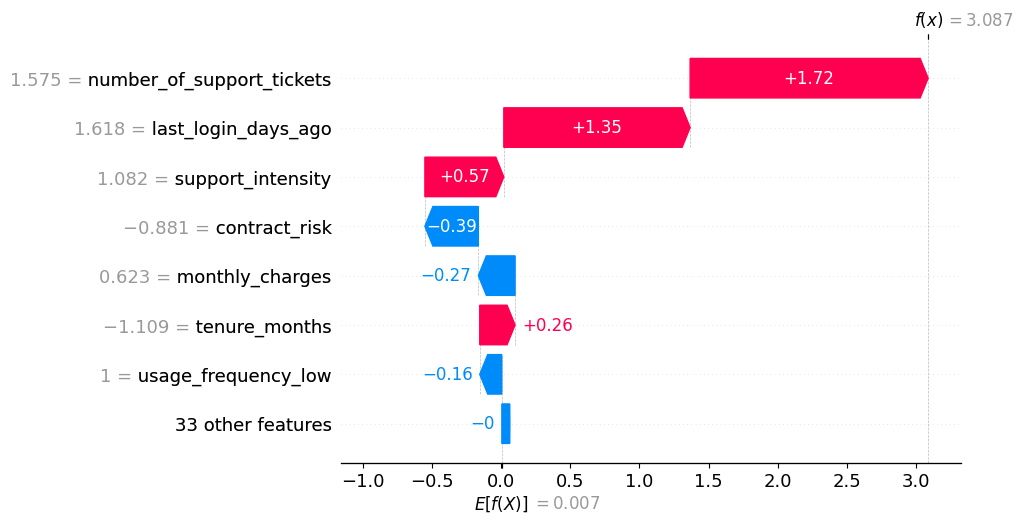

Text(0.5, 1.0, 'Why Customer #1 is Predicted to Churn (Prob: 95.6%)')

In [91]:
# Find a customer the model predicted as HIGH risk (probability > 0.85)
high_risk_indices = np.where(y_prob > 0.85)[0]
sample_idx = high_risk_indices[0] # Pick the first one

# Create a SHAP Explanation object for this single prediction
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_df.iloc[sample_idx].values,
    feature_names=X_test_df.columns
)

# Plot the Waterfall chart
plt.figure(figsize=(10, 6))
shap.waterfall_plot(explanation, max_display=8)
plt.title(f'Why Customer #{sample_idx} is Predicted to Churn (Prob: {y_prob[sample_idx]*100:.1f}%)')

## 6.Saving Model on HDD

In [93]:
import joblib

# Save the trained model
joblib.dump(xgb_model, r'C:\saas customer churn prediction\xgb_churn_model.pkl')

# Save the preprocessor (crucial for scaling/encoding new data)
joblib.dump(preprocessor, r'C:\saas customer churn prediction\preprocessor.pkl')

# Save the feature names and training medians/modes for filling default values
# This ensures the app doesn't crash if the user doesn't input every single feature
train_medians = X_train.median(numeric_only=True)
train_modes = X_train.mode().iloc[0]

joblib.dump(train_medians, r'C:\saas customer churn prediction\train_medians.pkl')
joblib.dump(train_modes, r'C:\saas customer churn prediction\train_modes.pkl')

print("✅ All artifacts saved successfully!")

✅ All artifacts saved successfully!
